In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/My Drive/Colab Notebooks/')

Mounted at /content/drive


In [ ]:
#import library package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df =pd.read_csv('/content/drive/My Drive/luas-areal-komoditi-kelapa-sawit-perkebunan-rakyat-menurut-kategori-area-di-aceh.csv', sep=';')
print("Number of datapoints:", len(df))
df.head()

Number of datapoints: 276


,kemendagri_kode_provinsi,kemendagri_nama_provinsi,kemendagri_kode_kabupaten_kota,kemendagri_nama_kabupaten_kota,tahun,kategori_area,luas_areal,satuan
0,11,Aceh,11.01,Kabupaten Aceh Selatan,2017,Tanaman belum menghasilkan,2012.0,Hektare
1,11,Aceh,11.02,Kabupaten Aceh Tenggara,2017,Tanaman belum menghasilkan,735.0,Hektare
2,11,Aceh,11.03,Kabupaten Aceh Timur,2017,Tanaman belum menghasilkan,11066.5,Hektare
3,11,Aceh,11.04,Kabupaten Aceh Tengah,2017,Tanaman belum menghasilkan,0.0,Hektare
4,11,Aceh,11.05,Kabupaten Aceh Barat,2017,Tanaman belum menghasilkan,4065.9,Hektare


In [ ]:
df.isnull().sum()

kemendagri_kode_provinsi          0
kemendagri_nama_provinsi          0
kemendagri_kode_kabupaten_kota    0
kemendagri_nama_kabupaten_kota    0
tahun                             0
kategori_area                     0
luas_areal                        6
satuan                            0
dtype: int64

In [ ]:
df.describe()

,kemendagri_kode_provinsi,kemendagri_kode_kabupaten_kota,tahun,luas_areal
count,276.0,276.000000,276.000000,270.000000
mean,11.0,11.233043,2018.500000,3538.638593
std,0.0,0.266475,1.120065,6351.484321
min,11.0,11.010000,2017.000000,0.000000
25%,11.0,11.060000,2017.750000,38.000000
50%,11.0,11.120000,2018.500000,677.250000
75%,11.0,11.180000,2019.250000,4093.520000
max,11.0,11.750000,2020.000000,37271.580000


Relative Plot Of Some Selected Features: A Data Subset


<Figure size 640x480 with 0 Axes>

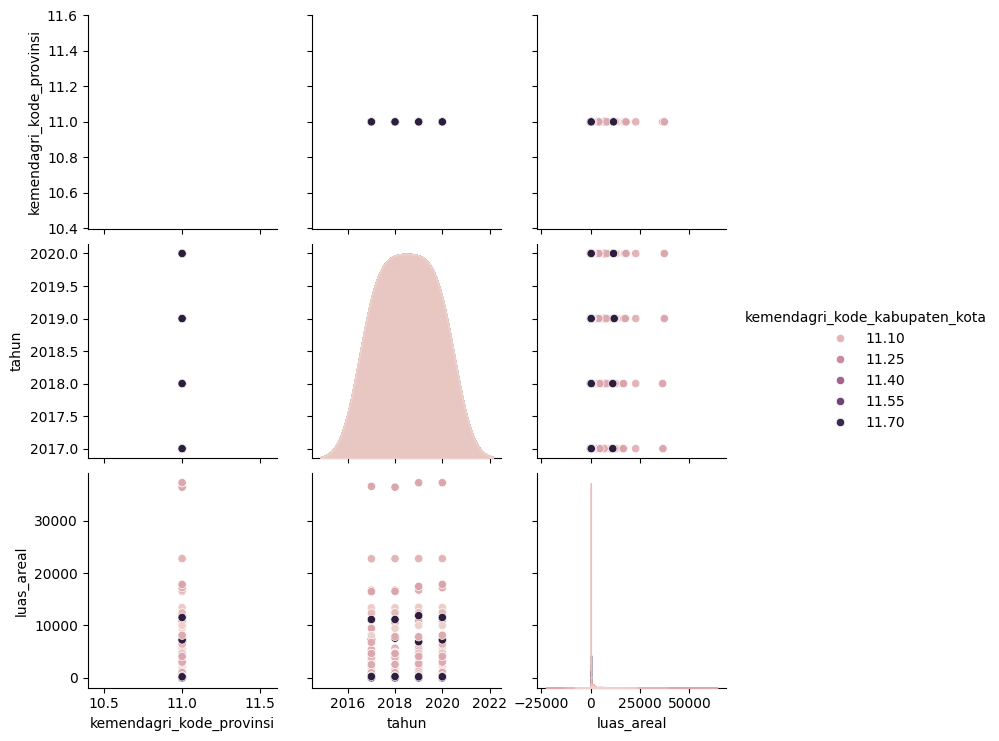

In [ ]:
To_Plot = ["kemendagri_kode_provinsi", "kemendagri_kode_kabupaten_kota", "tahun", "luas_areal"]

print("Relative Plot Of Some Selected Features: A Data Subset")
plt.figure()

sns.pairplot(df[To_Plot], hue="kemendagri_kode_kabupaten_kota")

plt.show()

In [ ]:
#import label encoder
from sklearn import preprocessing

#make an instance of Label Encoder
label_encoder = preprocessing.LabelEncoder()

# Encode each column separately
for column in ["kategori_area", "kemendagri_nama_provinsi", "kemendagri_nama_kabupaten_kota", "satuan"]:
    df[column] = label_encoder.fit_transform(df[column])

df.head()

,kemendagri_kode_provinsi,kemendagri_nama_provinsi,kemendagri_kode_kabupaten_kota,kemendagri_nama_kabupaten_kota,tahun,kategori_area,luas_areal,satuan
0,11,0,11.01,4,2017,0,2012.0,0
1,11,0,11.02,8,2017,0,735.0,0
2,11,0,11.03,9,2017,0,11066.5,0
3,11,0,11.04,7,2017,0,0.0,0
4,11,0,11.05,0,2017,0,4065.9,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   kemendagri_kode_provinsi        276 non-null    int64  
 1   kemendagri_nama_provinsi        276 non-null    int64  
 2   kemendagri_kode_kabupaten_kota  276 non-null    float64
 3   kemendagri_nama_kabupaten_kota  276 non-null    int64  
 4   tahun                           276 non-null    int64  
 5   kategori_area                   276 non-null    int64  
 6   luas_areal                      270 non-null    float64
 7   satuan                          276 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 17.4 KB


In [ ]:
unique_provinsi = df['kemendagri_nama_kabupaten_kota'].unique()
print(unique_provinsi)

[ 4  8  9  7  0  2 15 10 17  5 12  1 13  3 14  6 11 16 18 21 20 19 22]


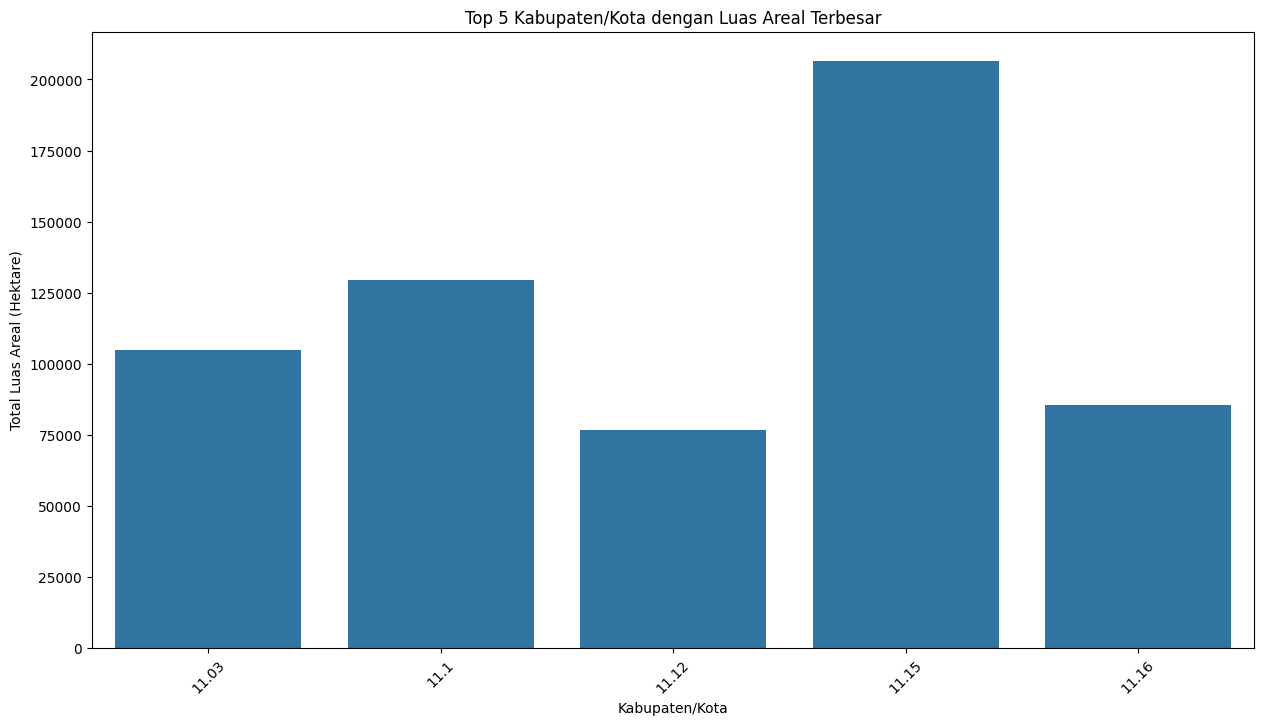

In [ ]:
# Menghitung total luas areal per kabupaten/kota
df_sum = df.groupby('kemendagri_kode_kabupaten_kota')['luas_areal'].sum().reset_index()

# Mengurutkan berdasarkan luas areal dan memilih 5 teratas
df_top5 = df_sum.sort_values(by='luas_areal', ascending=False).head(5)

# Plotting
plt.figure(figsize=(15, 8))
sns.barplot(x='kemendagri_kode_kabupaten_kota', y='luas_areal', data=df_top5)
plt.xlabel('Kabupaten/Kota')
plt.ylabel('Total Luas Areal (Hektare)')
plt.title('Top 5 Kabupaten/Kota dengan Luas Areal Terbesar')
plt.xticks(rotation=45)
plt.show()

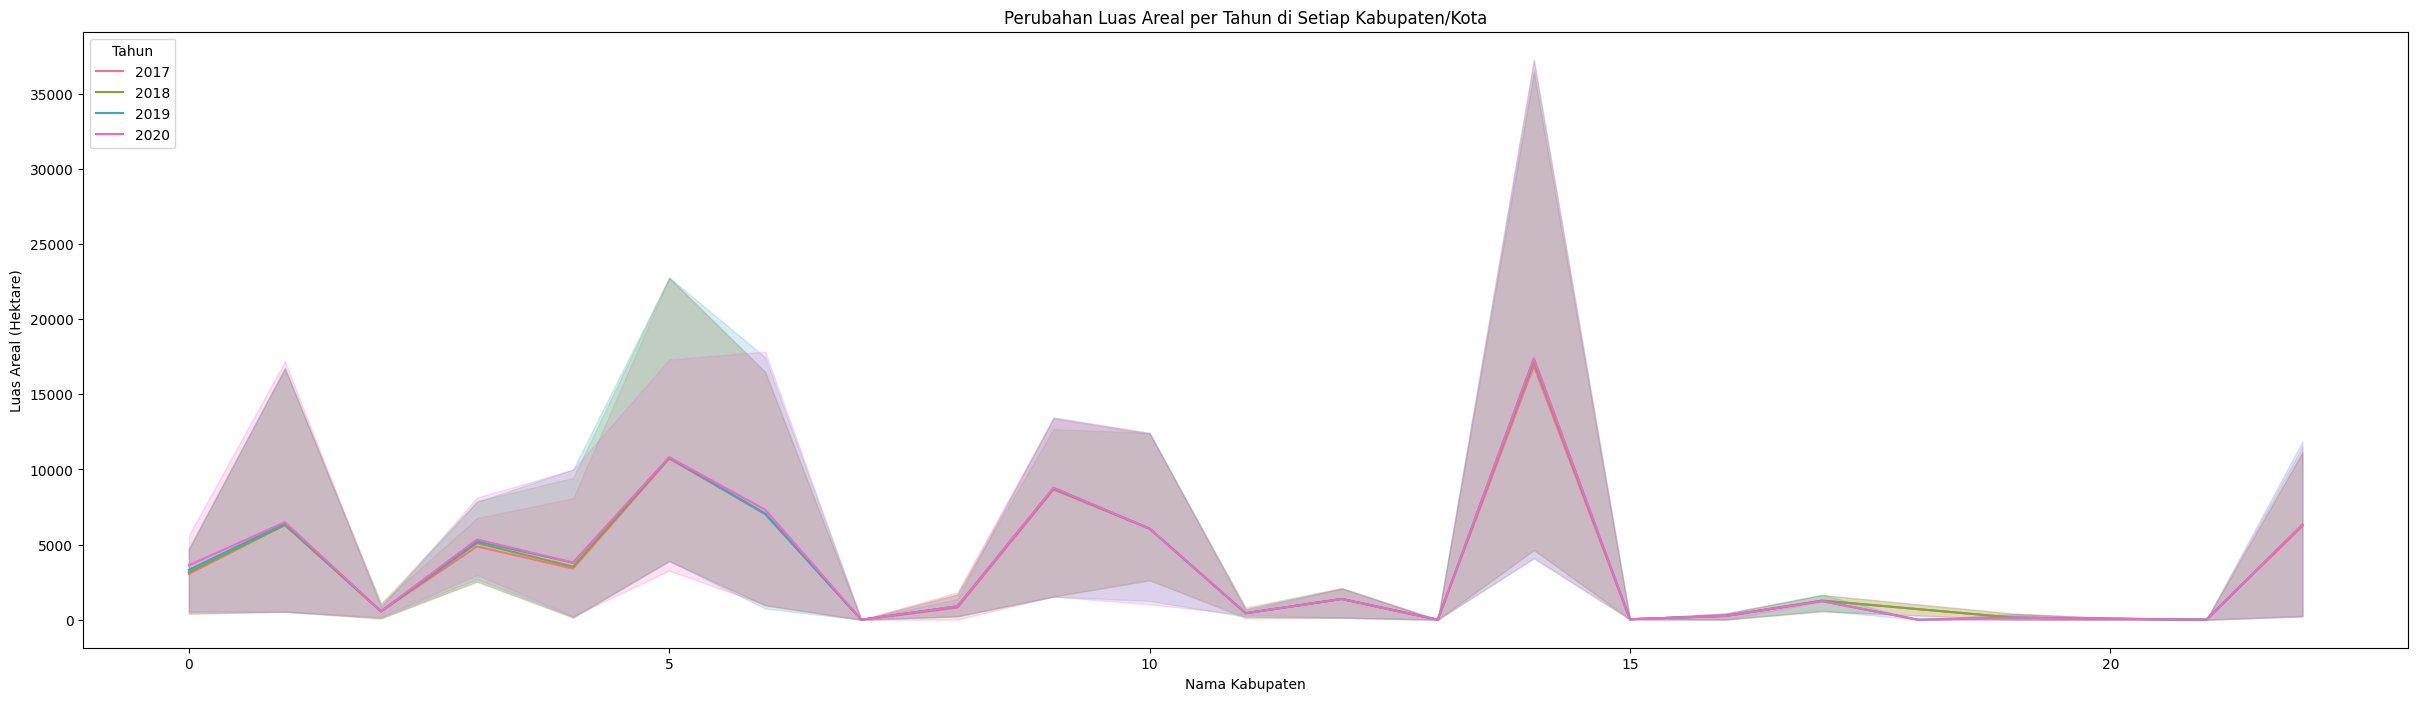

In [ ]:
from matplotlib.colors import ListedColormap

# Membuat palet warna kustom
custom_palette = ListedColormap(sns.color_palette("husl", 10).as_hex())

# Plotting dengan palet warna kustom
plt.figure(figsize=(30, 8))
sns.lineplot(x='kemendagri_nama_kabupaten_kota', y='luas_areal', hue='tahun', data=df, palette=custom_palette)
plt.xlabel('Nama Kabupaten')
plt.ylabel('Luas Areal (Hektare)')
plt.title('Perubahan Luas Areal per Tahun di Setiap Kabupaten/Kota')
plt.legend(title='Tahun', loc='upper left')
plt.show()

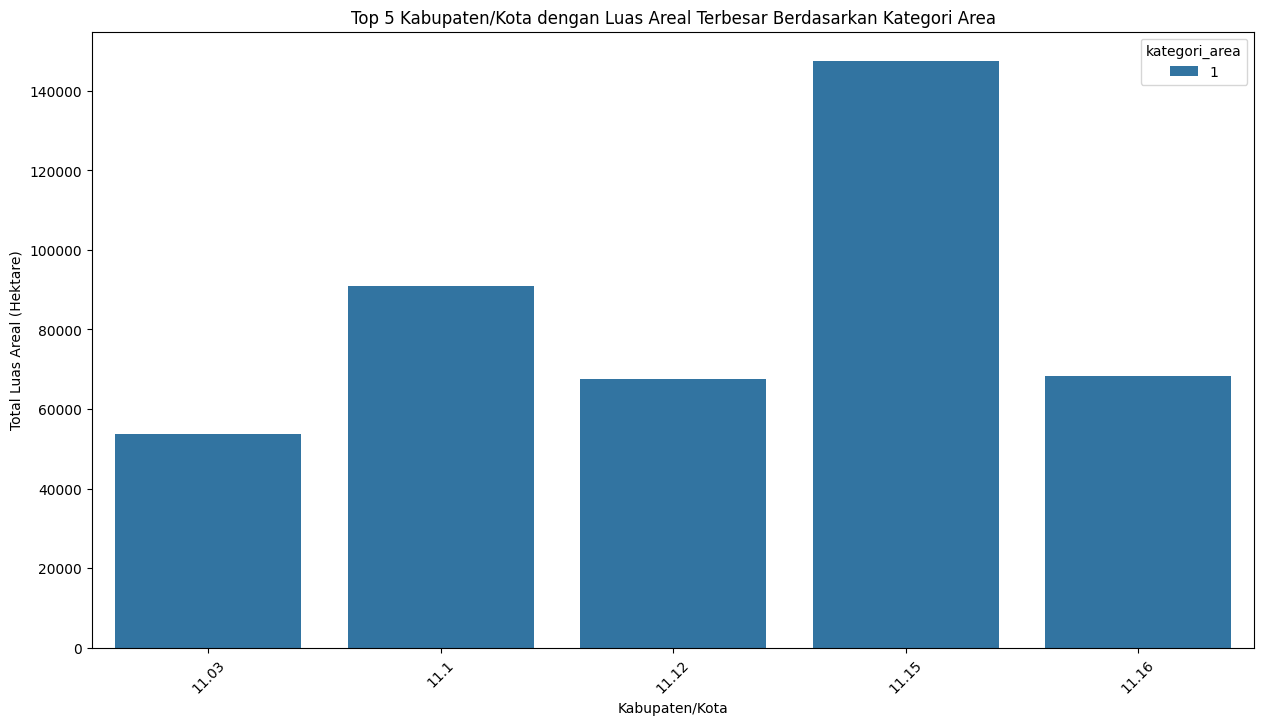

In [ ]:
# Menghitung total luas areal per kabupaten/kota dan kategori area
df_category = df.groupby(['kemendagri_kode_kabupaten_kota', 'kategori_area'])['luas_areal'].sum().reset_index()

# Mengurutkan berdasarkan luas areal dan memilih 5 teratas
df_top5 = df_category.sort_values(by='luas_areal', ascending=False).head(5)

# Plotting
plt.figure(figsize=(15, 8))
sns.barplot(x='kemendagri_kode_kabupaten_kota', y='luas_areal', hue='kategori_area', data=df_top5, palette='tab10')
plt.xlabel('Kabupaten/Kota')
plt.ylabel('Total Luas Areal (Hektare)')
plt.title('Top 5 Kabupaten/Kota dengan Luas Areal Terbesar Berdasarkan Kategori Area')
plt.xticks(rotation=45)
plt.show()